# Control de los equipos: analizador de espectro Keysight N9021B + generador de funciones Picotest G5100A

Este notebook controla en conjunto:
- el analizador de espectro/señales **Keysight N9021B** (clase `spectrum_analyzer`, en `class_spectrum_analyzer.py`), y
- el generador de funciones/arbitrario **Picotest G5100A** (clase `signal_generator`, en `class_signal_generator.py`),

ambos por red (protocolo VISA/SCPI). Se usan juntos para caracterizar los filtros: el generador inyecta un tono de prueba a la entrada y el analizador mide la respuesta a la salida.

Flujo típico de uso:
1. Conectar a los dos equipos (una vez cada uno).
2. Configurar y encender el generador (forma de onda, frecuencia, amplitud).
3. Elegir el modo de operación del analizador (acá: `"SA"` = Spectrum Analyzer, barrido en frecuencia).
4. Configurar el barrido: rango de frecuencias, RBW/VBW, cantidad de puntos.
5. Adquirir (`acquire()`) y graficar.
6. Guardar los datos a un `.csv` si sirven.
7. Apagar el generador y cerrar ambos equipos (`close_device()`) al terminar.

Las celdas de más abajo con `read_data(...)` y gráficos de comparación son ejemplos de análisis de mediciones ya guardadas (no hace falta el equipo conectado para esas).

In [1]:
pip install pyvisa

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pyvisa
import numpy as np
import time
import csv
import class_spectrum_analyzer as cspean
import class_signal_generator as csiggen
import matplotlib
import matplotlib.pyplot as plt
from scipy import signal

**Librerías:**
- `pyvisa`: protocolo de comunicación con instrumentos (VISA/SCPI).
- `class_spectrum_analyzer` (importada como `cspean`): nuestra clase que envuelve los comandos SCPI del N9021B.
- `class_signal_generator` (importada como `csiggen`): nuestra clase que envuelve los comandos SCPI del G5100A.
- `numpy`, `csv`: manejo de arrays y archivos.
- `matplotlib`: gráficos.
- `scipy.signal`: búsqueda de picos en el espectro (se usa más abajo, `find_peaks`).

In [4]:
#----------------------------------------------------------------------#
# Plot style configuration file and parameters
#----------------------------------------------------------------------#
# Load rcParams from a file
# plt.style.use('myclasses/rcparams_for_paper.mplstyle')
# plt.style.use('../mylibraries/rcparams_for_poster_or_presentation.mplstyle')

# Lines
matplotlib.rcParams['lines.linewidth'] = 1.2

# plt.style.use('classic')
# plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-pastel')
plt.rcParams['figure.figsize'] = [15, 8]
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Solo configuración estética de los gráficos (tamaño de figura, estilo, grosor de línea). No afecta la medición ni el equipo.

In [ ]:
sa_connection_info = 'TCPIP0::172.31.0.31::inst0::INSTR'
gen_connection_info = 'TCPIP0::172.31.0.20::inst0::INSTR'
base_data_path = r"C:\Users\nikip\OneDrive\LABO 6Y7" + "/"

- `sa_connection_info`: dirección VISA del analizador de espectro (IP dentro de la red del labo). **Cambiar acá** si el equipo tiene otra IP o se conecta por otro medio (GPIB/USB).
- `gen_connection_info`: dirección VISA del generador de funciones Picotest G5100A. **Cambiar acá** con la IP real del equipo (o usar `USB0::...::INSTR` / `GPIB0::<addr>::INSTR` si se conecta por otro medio).
- `base_data_path`: carpeta donde se guardan/leen los `.csv` de las mediciones (`save_data`/`read_data` arman la ruta completa como `base_data_path + nombre_archivo`).

In [6]:
keysight_N9021B = cspean.spectrum_analyzer(sa_connection_info, 
                                           force_stay_open = True,
                                           storage_path = base_data_path)

Object binded to Keysight N9021B Signal Analyzer


c:\Users\nikip\OneDrive\LABO 6Y7\programar\.venv\Lib\site-packages\pyvisa_py\tcpip.py:122: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(


Abre la conexión con el equipo y chequea que efectivamente sea el N9021B (si no, tira error). `force_stay_open=True` evita que la conexión se cierre sola después de cada adquisición, para poder medir varias veces seguidas sin reconectar cada vez.

Las tres celdas siguientes solo muestran/cambian el **timeout** de la comunicación VISA (en milisegundos): cuánto espera Python una respuesta del equipo antes de tirar un error de timeout. Conviene subirlo con `set_timeout(...)` si se van a hacer barridos lentos (RBW muy chica, muchos puntos, o promediado), porque si no la comunicación se puede cortar antes de que el equipo termine de medir.

In [7]:
print(keysight_N9021B.get_timeout())

2000


In [8]:
keysight_N9021B.set_timeout(60000)

In [9]:
print(keysight_N9021B.get_timeout())

60000


# Generador de funciones Picotest G5100A

Antes de medir con el analizador de espectro, hay que tener el generador conectado y con la señal de prueba activa (por ejemplo, el tono que se inyecta a la entrada del filtro). Usa la clase `signal_generator` definida en `class_signal_generator.py`.

In [ ]:
picotest_G5100A = csiggen.signal_generator(gen_connection_info)

Abre la conexión con el generador y chequea que efectivamente sea el G5100A (si no, tira error). A diferencia del analizador, esta clase no tiene `force_stay_open` ni `storage_path`: el generador no adquiere datos ni se auto-cierra entre operaciones, simplemente queda con la salida prendida hasta que se llame a `close_device()`.

In [ ]:
# Ejemplo: tono sinusoidal de prueba de 10 kHz, 200 mVpp, sin offset,
# sobre la carga de 50 ohm (valor por defecto del equipo).
picotest_G5100A.set_waveform("sine", frequency = 10e3, amplitude = 0.2, offset = 0)

`set_waveform(function, **kwargs)` selecciona la forma de onda (`"sine"`, `"square"`, `"ramp"`, `"pulse"`, `"noise"`, `"dc"`) y de paso configura los parámetros que se pasen como argumentos: `frequency` [Hz], `amplitude` [en la unidad configurada, Vpp por defecto], `offset` [V], `duty_cycle` [%, solo para onda cuadrada], `load` [ohms o `"INF"`], `unit` (`"VPP"`, `"VRMS"` o `"DBM"`). **Para cambiar el tono de prueba, esta es la celda a editar.**

In [ ]:
picotest_G5100A.get_device_configuration()

In [ ]:
picotest_G5100A.output_on()

`get_device_configuration()` le pregunta al equipo (vía SCPI) la configuración de salida actual (función, frecuencia, amplitud, offset, unidad, carga).

`output_on()` habilita la salida física (equivalente a apretar el botón `Output` del panel frontal) — el equipo arranca siempre con la salida apagada por seguridad. A partir de acá el generador está inyectando la señal de prueba; seguí con la configuración del analizador de espectro más abajo.

Antes de configurar nada hay que elegir el **modo de operación** del equipo. Acá se usa `"SA"` (Spectrum Analyzer): barrido en frecuencia, que es el modo relevante para medir el espectro a la salida de los filtros. Los otros modos (`"IQ"`, `"PN"`, `"RT"`) están nombrados en la clase pero todavía no están implementados del todo.

In [10]:
keysight_N9021B.set_mode("SA")

Spectrum Analyzer Class configured in Spectrum Analyzer mode


In [11]:
keysight_N9021B.get_device_mode()

'SA'

`get_device_mode()` solo devuelve el modo que quedó guardado en el objeto (el que se fijó arriba con `set_mode`); no le pregunta nada al equipo.

In [12]:
keysight_N9021B.get_device_configuration()

Spectrum Analyzer Class configured in Spectrum Analyzer mode
Retrieving device configuration ...


{'f_start': 0.0,
 'f_stop': 100000000.0,
 'f_center': 50000000.0,
 'span': 100000000.0,
 'rbw': 1000.0,
 'vbw': 1000.0,
 'n_points': 10001}

`get_device_configuration()` sí le pregunta al equipo (vía SCPI) qué configuración tiene puesta *en este momento* — útil para ver el estado real del instrumento, por ejemplo si alguien lo configuró a mano desde el panel antes de correr el notebook. Devuelve un diccionario con:

- `f_start`, `f_stop`: extremos del barrido en frecuencia [Hz].
- `f_center`, `span`: frecuencia central y ancho de la ventana [Hz] (equivalentes a f_start/f_stop).
- `rbw` (Resolution BandWidth) [Hz]: resolución en frecuencia del barrido — más chica = se distinguen mejor picos cercanos, pero el barrido tarda más.
- `vbw` (Video BandWidth) [Hz]: filtro de suavizado sobre la traza (baja el ruido visual, no cambia la resolución real).
- `n_points`: cantidad de puntos del barrido (largo de los arrays que después se grafican).

**La celda siguiente es solo un diccionario de ejemplo** (`new_configuration`) para tener a mano los nombres y unidades de los parámetros de barrido — no hace nada por sí solo. Hay que pasar estos mismos parámetros a `set_device_configuration(...)` (dos celdas más abajo) para que se apliquen de verdad en el equipo.

In [ ]:
new_configuration = {
                    "f_start": 10e6,   # Hz - borde inferior del barrido
                    "f_stop": 500e6,   # Hz - borde superior del barrido
                    "rbw": 30e3,       # Hz - Resolution BandWidth
                }

new_configuration

Acá se manda la configuración de verdad al equipo, con `set_device_configuration(...)`. Se le puede pasar cualquier combinación de estos parámetros (todos opcionales, en Hz salvo `n_points`):

`f_start`, `f_stop`, `f_center`, `span`, `rbw`, `vbw`, `n_points`, `ref_lvl`

Solo se cambian los que se pasan explícitamente; el resto queda como estaba en el equipo. **Para cambiar el barrido en una medición nueva, esta es la celda a editar.** El ejemplo de abajo pone `f_start=10e6`, `f_stop=50e6`, `rbw=10e3`, es decir: barrido de 10 a 50 MHz con RBW de 10 kHz.

In [ ]:
# Barrido de 10 MHz a 50 MHz con RBW = 10 kHz (todos los valores en Hz)
keysight_N9021B.set_device_configuration(f_start = 10e6, f_stop = 50e6, rbw = 10e3)

In [20]:
keysight_N9021B.get_device_configuration()

Spectrum Analyzer Class configured in Spectrum Analyzer mode
Retrieving device configuration ...


{'f_start': 10000000.0,
 'f_stop': 50000000.0,
 'f_center': 30000000.0,
 'span': 40000000.0,
 'rbw': 10000.0,
 'vbw': 10000.0,
 'n_points': 10001}

Se vuelve a leer la configuración para confirmar que los cambios se aplicaron correctamente en el equipo.

`acquire()` (celda siguiente) dispara un barrido nuevo, espera a que termine, y trae los datos medidos. En modo `"SA"` devuelve la tupla `(frecuencia, amplitud)`: `frequency_array` en Hz y `spectrum_signal` en dBm (mismo largo, `n_points`).

In [21]:
[frequency_array, spectrum_signal] = keysight_N9021B.acquire()

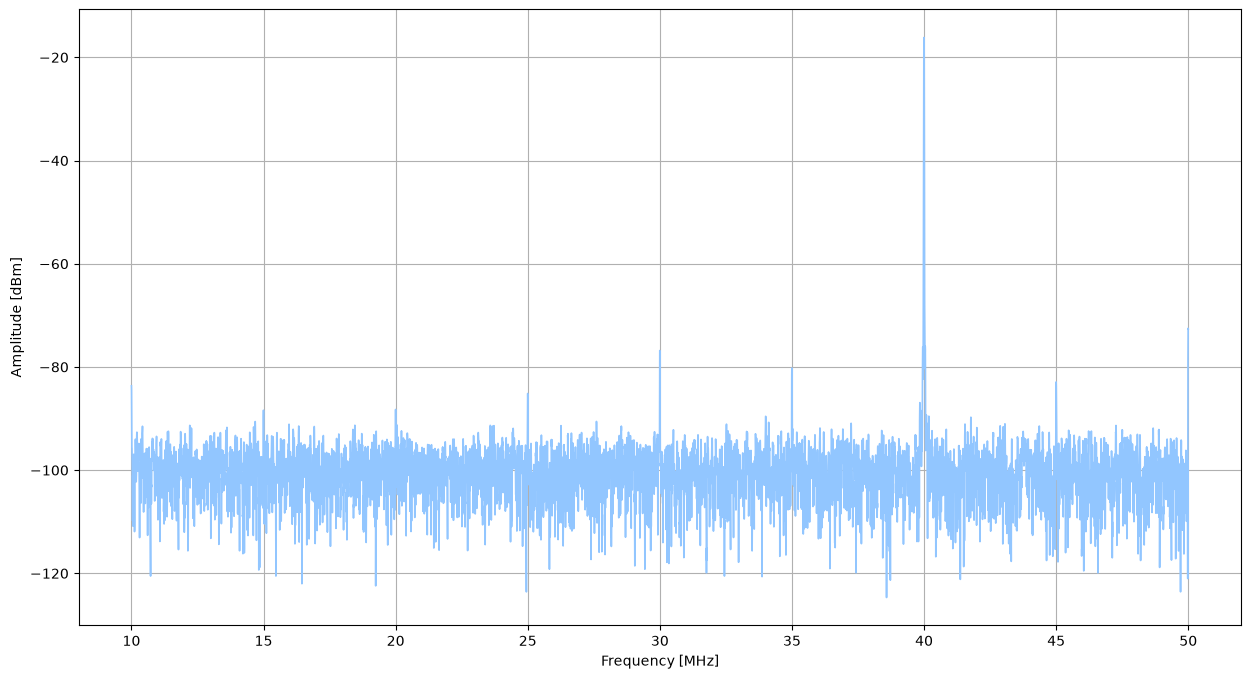

In [22]:
H1 =  plt.figure(1)
plt.plot(frequency_array / 1e6, spectrum_signal) 
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude [dBm]")
plt.grid()
# plt.xlim([6107,6108])

Grafica el espectro adquirido: eje X en MHz (por eso se divide `frequency_array` por `1e6`), eje Y en dBm.

# Barrido en frecuencia: generador + analizador de espectro

Para medir la respuesta en frecuencia de un filtro, se recorre una lista de frecuencias de prueba: en cada paso se configura y enciende el generador a esa frecuencia, se adquiere con el analizador de espectro, y se apaga el generador antes de pasar a la frecuencia siguiente (para no dejar un tono anterior superpuesto mientras se retuna). El resultado es una curva de amplitud de salida en función de la frecuencia de entrada.

**Antes de correr el barrido**, asegurate de que el analizador de espectro (`keysight_N9021B`) ya esté en modo `"SA"` y con un barrido (`f_start`/`f_stop`/`rbw`) que cubra el rango de `sweep_frequencies` de abajo — ver la sección de configuración del SA más arriba.

In [ ]:
# Barrido lineal: frecuencia inicial, final y paso [Hz], y amplitud del tono [Vpp].
# Editar según el rango de interés del filtro.
sweep_f_start = 1e3
sweep_f_stop = 500e3
sweep_f_step = 20e3
sweep_amplitude = 0.2

# + sweep_f_step/2 es solo para asegurarse de incluir el último punto
# (sweep_f_stop), ya que np.arange por si solo no lo garantiza por
# errores de redondeo de punto flotante.
sweep_frequencies = np.arange(sweep_f_start, sweep_f_stop + sweep_f_step / 2, sweep_f_step)
sweep_frequencies

`sweep_f_start`, `sweep_f_stop`, `sweep_f_step`: definen el barrido lineal de frecuencias de prueba [Hz] — arranca en `sweep_f_start`, termina en `sweep_f_stop` (inclusive) y avanza de a `sweep_f_step`. `sweep_amplitude`: amplitud del tono en Vpp (fija para todo el barrido). `sweep_frequencies` se arma solo a partir de esos tres valores con `np.arange(...)` — no hace falta escribir cada frecuencia a mano.

In [ ]:
sweep_results = []  # (f_test, frequency_array, spectrum_signal) de cada paso del barrido

for f_test in sweep_frequencies:
    # Configura el generador con la frecuencia de este paso y prende la salida.
    picotest_G5100A.set_waveform("sine", frequency = f_test, amplitude = sweep_amplitude, offset = 0)
    picotest_G5100A.output_on()
    time.sleep(0.5)  # margen para que la señal se estabilice antes de medir

    # Adquiere la traza completa del espectro con el analizador.
    [frequency_array, spectrum_signal] = keysight_N9021B.acquire()

    # Apaga el generador antes de pasar a la frecuencia siguiente.
    picotest_G5100A.output_off()

    # Guarda la traza completa a un .csv (uno por frecuencia de prueba), para
    # no perder nada si el barrido se corta a la mitad y para poder
    # reprocesarla despues con calma.
    sweep_filename = f"sweep_f_test_{f_test/1e3:.1f}kHz.csv"
    keysight_N9021B.save_data(sweep_filename)

    sweep_results.append((f_test, frequency_array, spectrum_signal))
    print(f"f_test = {f_test/1e3:.1f} kHz -> guardado en {sweep_filename}")

Por cada frecuencia de prueba: prende el generador ya configurado a `f_test`, espera 0.5 s para que se estabilice, dispara una adquisición con `acquire()` (que también espera a que el barrido del SA termine) y apaga el generador. La traza completa (`frequency_array`, `spectrum_signal`) se guarda tanto en `sweep_results` como en un `.csv` distinto por cada `f_test` (con `save_data`), a medida que avanza el barrido — así no se pierde nada si el barrido se corta a mitad de camino, y se puede reprocesar cualquier traza después sin tener que repetir la medición. La búsqueda del pico real se hace más abajo, en Python, en vez de confiar en el peak search del equipo (que puede engancharse a ruido en vez de a la señal). Si el barrido del SA es lento (RBW muy chica), puede convenir subir el `time.sleep(...)` o el timeout del SA (ver más arriba).

In [ ]:
# Busca el pico real en cada traza guardada con scipy.signal.find_peaks, y
# se queda con el pico mas cercano a f_test (por si hay ruido u otras
# señales en la traza). 'height' es el piso minimo en dBm para considerar
# algo un pico -- ajustar segun el piso de ruido real del equipo/filtro.
peak_height_dBm = -80

response_peak_freq = []
response_amplitude_dBm = []

for f_test, frequency_array, spectrum_signal in sweep_results:
    peaks_bin, _ = signal.find_peaks(spectrum_signal, height = peak_height_dBm)

    if len(peaks_bin) == 0:
        # No se encontro ningun pico por encima del umbral: se usa el
        # maximo de toda la traza como ultimo recurso.
        peak_idx = np.argmax(spectrum_signal)
    else:
        # De los picos encontrados, el mas cercano a f_test.
        peak_idx = peaks_bin[np.argmin(np.abs(frequency_array[peaks_bin] - f_test))]

    response_peak_freq.append(frequency_array[peak_idx])
    response_amplitude_dBm.append(spectrum_signal[peak_idx])

response_peak_freq = np.array(response_peak_freq)
response_amplitude_dBm = np.array(response_amplitude_dBm)

H2 = plt.figure(2)
plt.plot(sweep_frequencies / 1e3, response_amplitude_dBm, 'o-')
plt.xlabel("Frequency [kHz]")
plt.ylabel("Amplitude [dBm]")
plt.xscale('log')
plt.grid()

Arma la curva de respuesta en frecuencia del filtro: para cada traza guardada en `sweep_results`, usa `scipy.signal.find_peaks` (la misma función que se usa más abajo, en los ejemplos de análisis) para encontrar los picos reales por encima de `peak_height_dBm`, y se queda con el más cercano a `f_test`. Es más robusto que el peak search del equipo o que tomar directamente el punto más cercano a `f_test` en la traza. Ajustá `peak_height_dBm` según el piso de ruido que veas en las trazas — si un pico esperado no aparece, probablemente esté por debajo de ese umbral. `plt.xscale('log')` es útil si el barrido cubre varias décadas; comentá esa línea si preferís escala lineal.

# Graficar una de las trazas guardadas en el barrido

In [ ]:
# Ejemplo: graficar la traza guardada para f_test = 0.1 kHz.
[freq_sweep_ex, spec_sweep_ex] = keysight_N9021B.read_data('sweep_f_test_0.1kHz.csv', mode="SA")

H3 = plt.figure(3)
plt.plot(freq_sweep_ex / 1e3, spec_sweep_ex)
plt.xlabel("Frequency [kHz]")
plt.ylabel("Amplitude [dBm]")
plt.grid()

`read_data(...)` lee cualquiera de los `.csv` guardados durante el barrido (`sweep_f_test_<frecuencia>kHz.csv`, dentro de `base_data_path`) sin necesidad de tener el equipo conectado. Cambiá el nombre de archivo por el que quieras inspeccionar — reemplazá `<frecuencia>` por el valor de `f_test` correspondiente, en kHz con un decimal (por ejemplo `sweep_f_test_2.5kHz.csv`).

In [ ]:
# keysight_N9021B.save_data('zcu216_acq_with_add_tone_single_tone_test_1.csv')
# keysight_N9021B.save_data('zcu216_acq_with_add_tone_optimized_single_tone_test_1.csv')

# keysight_N9021B.save_data('zcu216_acq_with_write_raw_data.csv')
# keysight_N9021B.save_data('zcu216_acq_with_add_tones_nmuller.csv')
# keysight_N9021B.save_data('zcu216_acq_with_write_raw_data_single_tone_nmuller.csv')



# keysight_N9021B.save_data('vna_output_port_1.csv')
# keysight_N9021B.save_data('vna_output_port_1_zoom.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_OFF.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_HOLD.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_OFF.csv')

# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_1_NPhi0__10kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_1p5_NPhi0__10kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_2_NPhi0__10kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_2p5_NPhi0__10kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_3_NPhi0__10kHz.csv')

# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_1_NPhi0__1kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_1p5_NPhi0__1kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_2_NPhi0__1kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_2p5_NPhi0__1kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_rf_ON_Trigger_CONT_ramp_3_NPhi0__1kHz.csv')

# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_1_NPhi0__2kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_1_NPhi0__10kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_1_NPhi0__12p5kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_2_NPhi0__1kHz.csv')
# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_1_NPhi0__3kHz.csv')

# keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_OFF_after_all.csv')
keysight_N9021B.save_data('vna_output_port_1_to_cryo_zoom_x2_rf_ON_Trigger_CONT_ramp_OFF_after_all_LNA_noGND.csv')



`save_data(nombre_archivo)` guarda `frequency_array`/`spectrum_signal` (la última adquisición) en un `.csv` dentro de `base_data_path`, con columnas `Frequency` y `Amplitude`. Las líneas comentadas (`#`) son nombres de archivos de mediciones anteriores — quedan como registro/historial, no se ejecutan. La línea activa (sin `#`) es la que efectivamente guarda el archivo de la medición actual.

In [ ]:
[freq_addt, spec_addt] = keysight_N9021B.read_data('zcu216_acq_with_add_tones_nmuller.csv', mode="SA")
[freq_wraw, spec_wraw] = keysight_N9021B.read_data('zcu216_acq_with_write_raw_data_nmuller.csv', mode="SA")

`read_data(nombre_archivo, mode="SA")` lee un `.csv` ya guardado y devuelve `(frecuencia, amplitud)`, sin necesidad de tener el equipo conectado — sirve para volver a analizar/graficar mediciones viejas.

In [ ]:
H1 =  plt.figure(1)
plt.plot(freq_addt / 1e6, spec_addt, "r", label = "add_tones()") 
plt.plot(freq_wraw / 1e6, spec_wraw, "b", label = "write_raw_data()") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude [dBm]")
plt.grid()
plt.legend()
# plt.xlim(28, 35)
# plt.xlim(50, 55)
# plt.xlim(58, 62)
plt.xlim(72, 84)
# plt.xlim(90, 94)
# plt.xlim(120, 125)
# plt.savefig("/srv/data/measurements/lferreyro/sdr_measurements/zcu216_signal_generation_characterization/stimcore_tests_zoom.png")

In [ ]:
keysight_N9021B.close_device()

# Apagar y cerrar el generador

In [ ]:
picotest_G5100A.close_device()

`close_device()` (del N9021B) deja al equipo en modo Spectrum Analyzer con barrido continuo (como si se lo usara a mano) y cierra la conexión VISA. Conviene llamarla al terminar de medir, sobre todo si se usó `force_stay_open=True`.

`close_device()` (del G5100A) apaga la salida y cierra la conexión VISA.

De acá en adelante, las celdas son ejemplos de análisis de mediciones guardadas en experimentos anteriores (comparación entre métodos de generación de tonos, búsqueda de picos con `scipy.signal.find_peaks`) — quedan como referencia, no hace falta correrlas para una medición nueva.

In [ ]:
[freq_addt_st, spec_addt_st] = keysight_N9021B.read_data('zcu216_acq_with_add_tone_single_tone_deltaFreq.csv', mode="SA")
[freq_wraw_addt_st_bis, spec_addt_st_bis] = keysight_N9021B.read_data('zcu216_acq_with_add_tone_single_tone_deltaFreqBis.csv', mode="SA")
[freq_wraw_addt_st_bis_2, spec_addt_st_bis_2] = keysight_N9021B.read_data('zcu216_acq_with_add_tone_single_tone_deltaFreqBis_2.csv', mode="SA")
[freq_wraw_st, spec_wraw_st] = keysight_N9021B.read_data('zcu216_acq_with_write_raw_data_single_tone_nmuller.csv', mode="SA")

In [ ]:
H1 =  plt.figure(1)
# plt.plot(freq_addt_st / 1e6, spec_addt_st, "r", label = "add_tones() - DeltaF = Fs/((slices*(2*octets_per_clk))/2)") 
# plt.plot(freq_wraw_addt_st_bis / 1e6, spec_addt_st_bis, "b", label = "add_tones() - DeltaF = Fs/slice") 
# plt.plot(freq_wraw_addt_st_bis_2 / 1e6, spec_addt_st_bis_2, "g", label = "add_tones() - DeltaF = Fs/(slice/2)") 
plt.plot(freq_wraw_st / 1e6, spec_wraw_st, "k", label = "write_raw_data() single tone") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude [dBm]")
plt.grid()
plt.legend()
# plt.xlim(28, 35)

In [ ]:
[freq_addt, spec_addt] = keysight_N9021B.read_data('zcu216_acq_with_add_tone_single_tone_test_1.csv', mode="SA")
[freq_wraw_addt_opt, spec_addt_opt] = keysight_N9021B.read_data('zcu216_acq_with_add_tone_optimized_single_tone_test_1.csv', mode="SA")

print(len(spec_addt_opt))

In [ ]:
H1 =  plt.figure(1)
plt.plot(freq_addt / 1e6, spec_addt, "r", label = "add_tones() - DeltaF = Fs/((slices*(2*octets_per_clk))/2)") 
plt.plot(freq_wraw_addt_opt / 1e6, spec_addt_opt, "b", label = "add_tones_optimized()") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude [dBm]")
plt.grid()
plt.legend()
# plt.xlim(31.49, 31.51)

`scipy.signal.find_peaks` busca picos locales en el espectro. `height=-130` es el piso mínimo en dBm para considerar algo un pico (filtra el ruido de piso), y `distance=100` es la separación mínima entre picos en **cantidad de puntos** (no en Hz) — si el barrido tiene otra cantidad de puntos (`n_points`) hay que reajustar este valor.

In [ ]:
peaks_bin, d = signal.find_peaks(spec_addt_opt, height=-130, distance = 100)
print(peaks_bin)
print(d)
print(freq_wraw_addt_opt[peaks_bin] / 1e6)
print(np.diff(freq_wraw_addt_opt[peaks_bin] / 1e6))

In [ ]:
H1 =  plt.figure(1)
plt.plot(freq_wraw_addt_opt / 1e6, spec_addt_opt, "b", label = "add_tones_optimized()") 
plt.plot(freq_wraw_addt_opt[peaks_bin] / 1e6, spec_addt_opt[peaks_bin], '*', label = "Peaks") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude [dBm]")
plt.grid()
plt.legend()
# plt.xlim(31.49, 31.51)